# Reproducing the paper's measurement figures

Four figures, all built from data shipped with this repository:

1. **Radio population** — every impairment, every radio, faceted by gain
2. **Cross-session replication** — July against an August re-capture, per parameter
3. **Representative-device distributions** — the per-run distributions the
   generator samples, for one radio and configuration
4. **Fitted blocks vs measured deviation** — how much of the real per-symbol
   deviation the generator reproduces

The first three need no captures: everything comes from
`radio_characterisation.json` (23 radios x 6 configurations x 100 runs) and
`repeat_log.json` (the August re-capture). The fourth plots pre-extracted
deviation arrays, since producing them needs the raw captures. Run time is
well under a minute.

Requirements beyond the generator itself: `matplotlib` and `scipy`.

## Setup

Run this notebook from the repository root — the figure scripts read the logs by relative path and write into `figures/`.

In [1]:
import subprocess
import sys
from pathlib import Path

from IPython.display import Image, display

REPO = Path.cwd()
assert (REPO / "data" / "radio_characterisation.json").exists(), (
    "run this notebook from the repository root")
FIGURES = REPO / "figures"
FIGURES.mkdir(exist_ok=True)


def run(script, *args):
    """Run a figure script and echo whatever it reports."""
    result = subprocess.run(
        [sys.executable, str(REPO / "analysis_scripts" / script), *args],
        capture_output=True, text=True, cwd=REPO)
    print(result.stdout.strip() or result.stderr.strip())
    if result.returncode != 0:
        raise RuntimeError(f"{script} failed:\n{result.stderr}")


print("repository:", REPO)

repository: C:\Users\vngu6249\OneDrive - The University of Sydney (Staff)\Documents\Signal_Generation\github_generator


## What is in the logs

`radio_characterisation.json` holds one record per run. Not every session is
usable: four early captures were recorded at the wrong carrier (2400.0 MHz and
433.0 MHz rather than 2450.0 and 433.92) and are excluded by name wherever they
appear. Two radios were re-captured afterwards and it is those corrected
sessions that the figures use.

In [2]:
import json
import re
from collections import defaultdict

log = json.loads((REPO / "data" / "radio_characterisation.json").read_text())
sessions = defaultdict(set)
for record in log.values():
    if not isinstance(record, dict):
        continue
    match = re.match(r"^TX(\w+)_RXBB60_(\d+)/g", str(record.get("session", "")))
    if match:
        sessions[match.group(1)].add(match.group(2))

print(f"{len(sessions)} radios, {sum(len(s) for s in sessions.values())} radio-sessions")
print(f"{len(log):,} run records")

repeat = json.loads((REPO / "data" / "repeat_log.json").read_text())
radios_repeat = {m.group(1) for k in repeat
                 if (m := re.match(r"^TX(\w+)_RXBB60_REPEAT/", k))}
print(f"{len(radios_repeat)} radios in the August re-capture")

23 radios, 32 radio-sessions
23,478 run records
22 radios in the August re-capture


## 1. Radio population

Every radio, every band, faceted by transmit gain. Error bars are the
run-to-run standard deviation *within a session* — each radio contributes one
session, chosen explicitly rather than averaged, since combining sessions would
mix capture days.

The six parameters are the ones a receiver can measure directly without
fitting: reference oscillator, sampling clock, LO leakage, IQ imbalance and
SNR.

5 radios have >1 session; one chosen for each:
    30BF795  -> session 104619  (100 runs per config)
    30BF7C1  -> session 092130  (100 runs per config)
    30EAE34  -> session 120749  (100 runs per config)
    30ECB71  -> session 143905  (100 runs per config)
    30ECB84  -> session 134013  (100 runs per config)
23 radios: 30BF795, 30BF7BE, 30BF779, 30BF7A4, 30BF7AB, 30BF796, 30BF7B6, 30BF7C1, 30ECB81, 30EAE76, 30ECB6B, 30ECB8A, 30ECBAD, 30ECB80, 30EAE34, 30ECB67, 30EAE27, 30ECB84, 30ECB66, 30ECB71, 30ECBC5, 30EAE54, 30ECBBC
saved -> C:\Users\vngu6249\OneDrive - The University of Sydney (Staff)\Documents\Signal_Generation\github_generator\figures\A4s_radio_population_bars_core.png


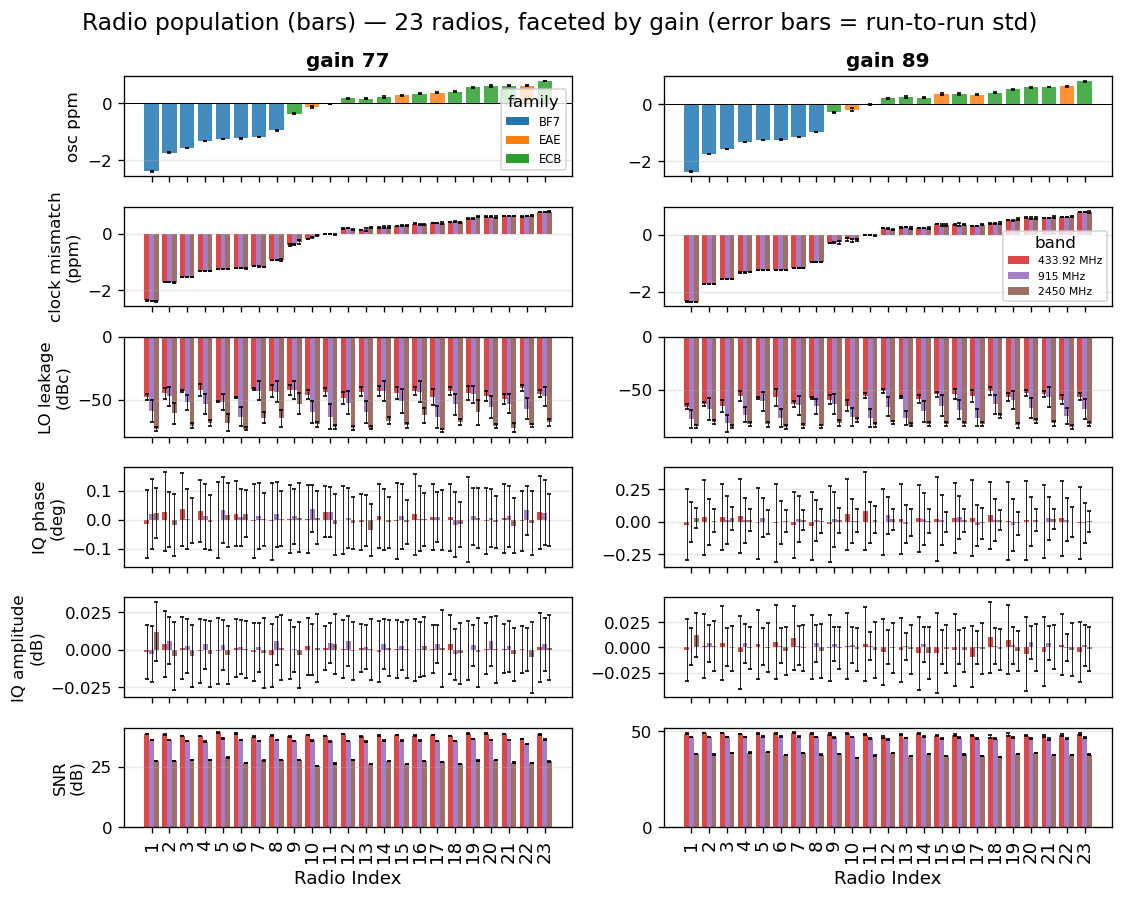

In [3]:
run("radio_population_bars.py", "core")
display(Image(str(FIGURES / "A4s_radio_population_bars_core.png")))

Two things to read off it:

- the **oscillator and clock** rows separate the radios cleanly and the error
  bars are invisibly small — these are the strong fingerprints
- the **IQ rows** have error bars that dwarf the bars themselves: run-to-run
  scatter exceeds the between-radio differences, so IQ carries little device
  information in this fleet

Pass `all` instead of `core` for the full ten-parameter version, or a
comma-separated list to select your own.

## 2. Cross-session replication

The same radios recorded again roughly three weeks later. Each panel z-scores
both sessions with statistics pooled across them, so a parameter that
identifies a device lands on the diagonal.

Two filters apply, both reported when the cell runs: the four bad-carrier
sessions are dropped, and a pair is only used when the two captures are at
least 20 days apart — a "cross-day" result means little if the captures are
days apart.

cross-day filter: 13 radios at >= 20 days   (dropped 7 too close, 3 unpaired)
  -> C:\Users\vngu6249\OneDrive - The University of Sydney (Staff)\Documents\Signal_Generation\github_generator\figures\A4s_session_replication_z_core.png


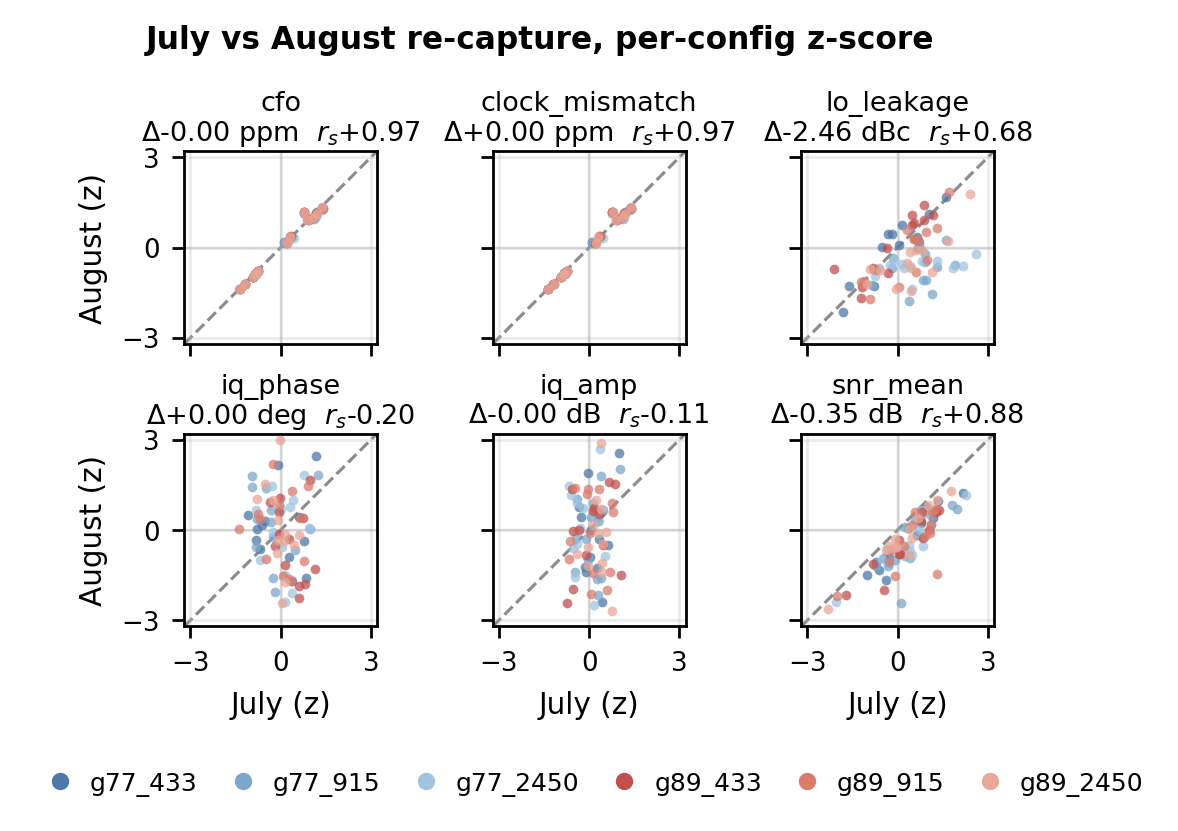

In [4]:
run("fig_session_replication_z.py", "core")
display(Image(str(FIGURES / "A4s_session_replication_z_core.png")))

The ordering is the result: the crystal-derived parameters replicate
almost perfectly, SNR and LO leakage partially, and IQ not at all.

One caveat worth knowing. CFO and sampling clock mismatch are **not**
independent measurements — both estimate the same reference oscillator, and in
these captures they correlate at pearson r = 1.0000 with a difference of
0.0008-0.0017 ppm. Two panels, one physical quantity.

## 3. Representative-device distributions

The per-run distributions the generator samples from, for one radio and
configuration, with the fitted model drawn over each histogram.

Solid curves are distributions the generator draws. The single dashed curve on
the CFO panel is not a model: it is the injected marginal broadened by the CFO
estimator's own error, and it exists to explain why that histogram is so much
wider than the oscillator actually is.

-> C:\Users\vngu6249\OneDrive - The University of Sydney (Staff)\Documents\Signal_Generation\github_generator\figures\A4s_input_distributions_30BF779_89_433.png
  Sampling clock mismatch                      -1.5655 +/- 0.0009283  ppm   n=100
  CFO  = clock mismatch -0.0102 ppm            -1.5753 +/- 0.00536    ppm   n=100
  AWGN (SNR)                                    49.076 +/- 0.05878    dB    n=100
  IQ amplitude imbalance                     0.0043606 +/- 0.03683    dB    n=100
  IQ phase imbalance                          0.036053 +/- 0.2539     deg   n=100
  TX LO leakage                                -68.055 +/- 5.58       dBc   n=100

  ref osc sd 0.00092 ppm (clock estimator)
  CFO estimator noise 0.00528 ppm -> total 0.00536 ppm   (measured CFO sd 0.00536)


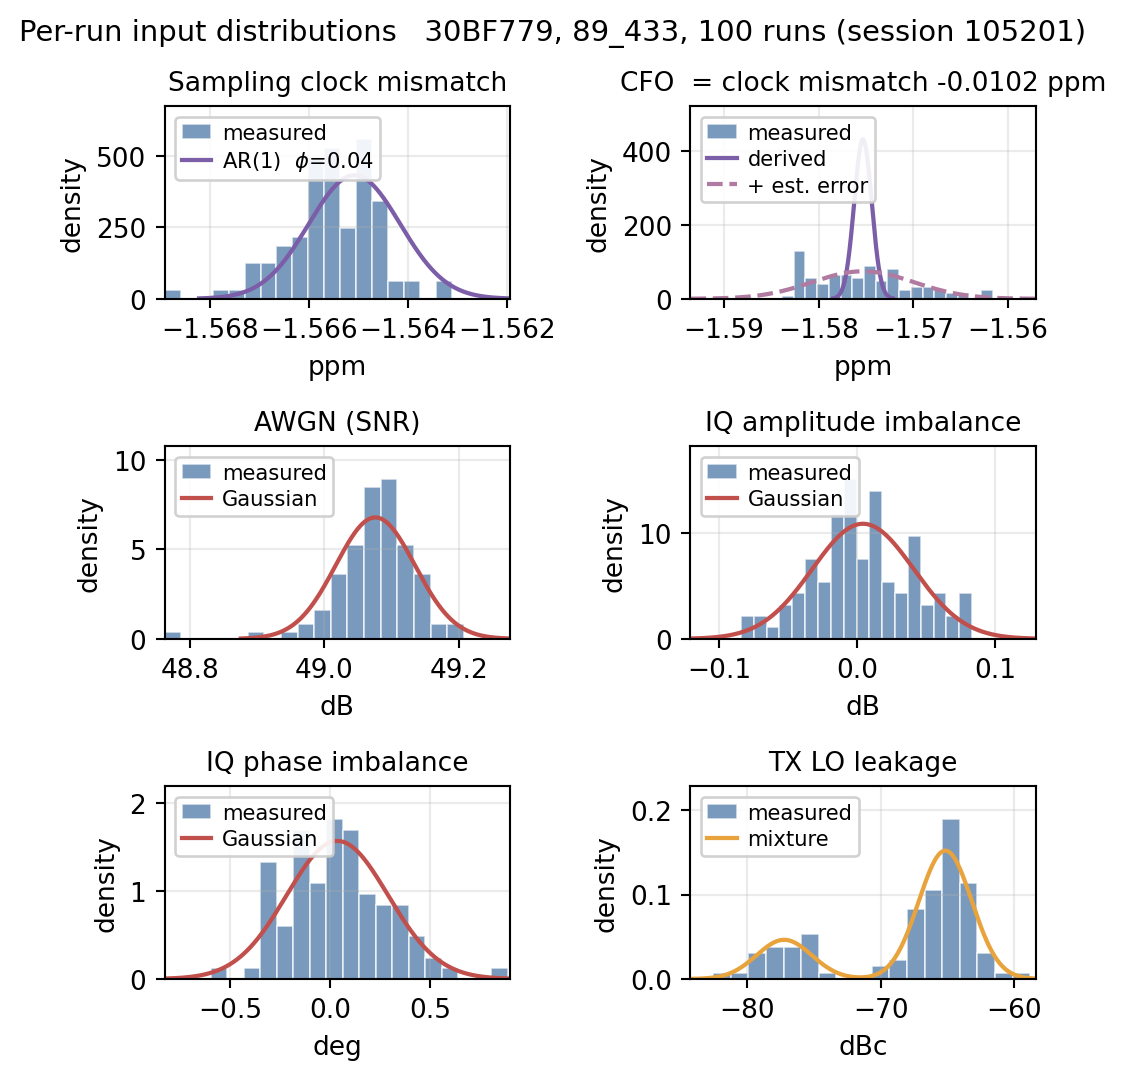

In [5]:
run("fig_input_distributions.py", "30BF779", "89_433")
display(Image(str(FIGURES / "A4s_input_distributions_30BF779_89_433.png")))

Worth noting on two panels:

- **CFO and the sampling clock are one oscillator measured twice**, so the
  generator draws the reference once and derives CFO from it. On this device
  the CFO estimate is the noisier of the two by a factor of 5.8, which is why
  its histogram is so much wider than the injected marginal -- the dashed curve
  is that marginal broadened by the estimator's own error. The factor varies a
  lot across the fleet (median 1.02 over 138 radio/configurations, reaching 9
  on some), and the generator always takes the oscillator's spread from the
  clock estimate for that reason.
- **TX LO leakage** is bimodal here and on most radio/configurations, so a
  two-component mixture is fitted where the evidence supports it (BIC margin
  -10 plus a degeneracy guard) and a single Gaussian is kept where it does not.

Any radio and configuration in the log can be substituted:

-> C:\Users\vngu6249\OneDrive - The University of Sydney (Staff)\Documents\Signal_Generation\github_generator\figures\A4s_input_distributions_30BF7B6_77_433.png
  Sampling clock mismatch                      -1.1556 +/- 0.001446   ppm   n=100
  CFO  = clock mismatch -0.0084 ppm            -1.1635 +/- 0.003547   ppm   n=100
  AWGN (SNR)                                    37.264 +/- 0.2035     dB    n=100
  IQ amplitude imbalance                     -0.001613 +/- 0.01963    dB    n=100
  IQ phase imbalance                        -0.0059858 +/- 0.1285     deg   n=100
  TX LO leakage                                -41.656 +/- 0.6866     dBc   n=100

  ref osc sd 0.00144 ppm (clock estimator)
  CFO estimator noise 0.00324 ppm -> total 0.00354 ppm   (measured CFO sd 0.00355)


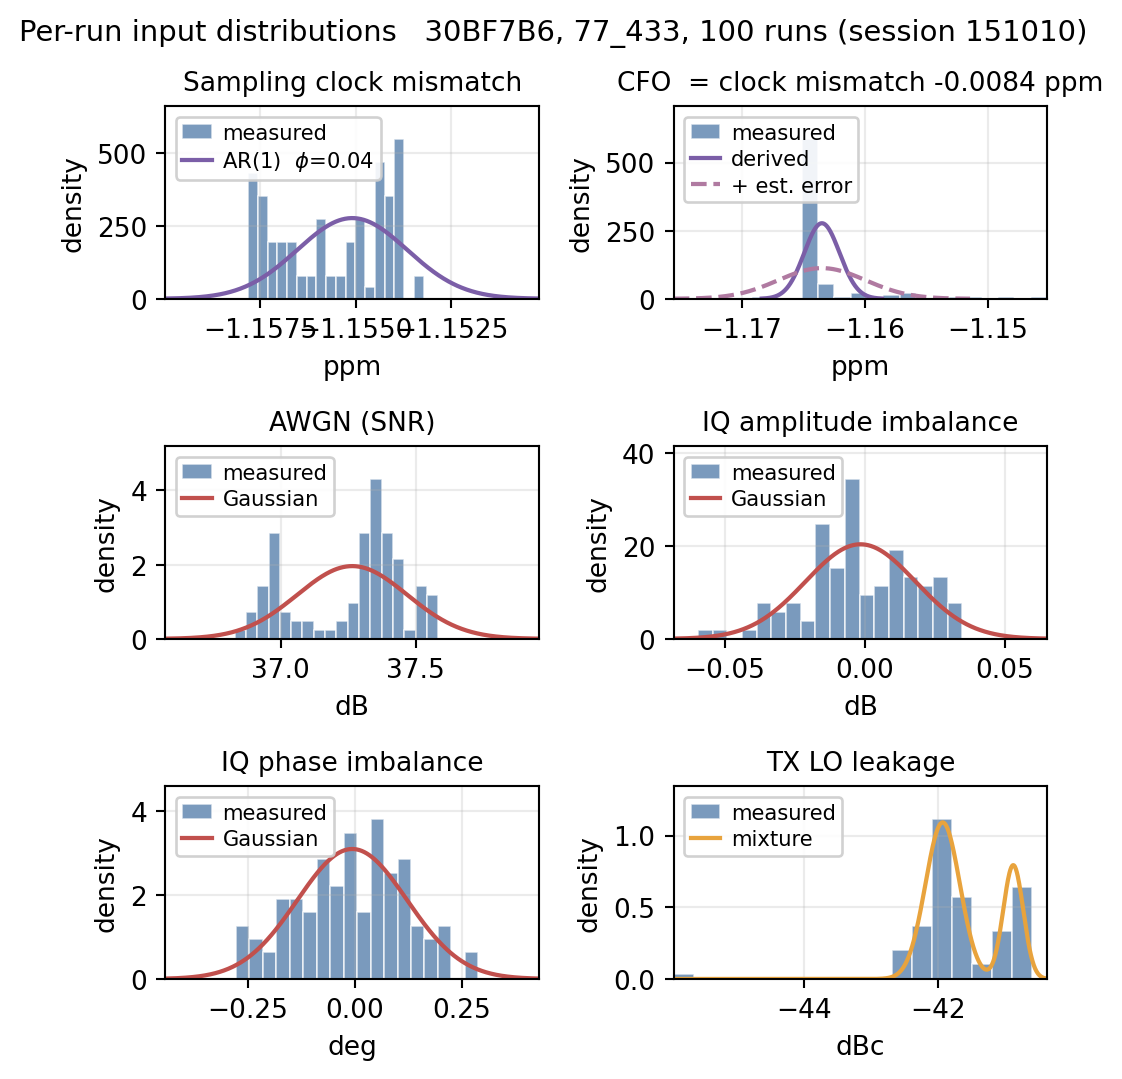

In [6]:
# e.g. a different device, or the same device at low gain
run("fig_input_distributions.py", "30BF7B6", "77_433")
display(Image(str(FIGURES / "A4s_input_distributions_30BF7B6_77_433.png")))

## 4. Fitted blocks vs the measured deviation

How much of the real per-symbol deviation the generator actually reproduces.
Left column is the real capture with all 100 runs overlaid; right column is the
pooled real distribution against two synthetic cases — the full chain, and the
chain with the three burst-average-fitted blocks (ISI taps, PA, burst
transient) switched off.

This one is **plot-only**. Producing the arrays needs the raw captures, which
are not shipped here, plus about half an hour of synthesis, so the extracted
deviations are packaged in `fitted_blocks_30BF779_89_433.npz` instead.

30BF779 / 89_433   100 runs x 40 bursts
    REAL amplitude deviation  sd  5.117 %
      all fitted blocks    sd  4.919 %    96.1 % of real
      AWGN + PN            sd  0.645 %    12.6 % of real
      missing term 1.410 %
    REAL phase deviation      sd  2.815 deg
      all fitted blocks    sd  2.132 deg    75.7 % of real
      AWGN + PN            sd  0.817 deg    29.0 % of real
      missing term 1.838 deg
  -> C:\Users\vngu6249\OneDrive - The University of Sydney (Staff)\Documents\Signal_Generation\github_generator\figures\A4s_fitted_blocks_dist_30BF779_89_433.png


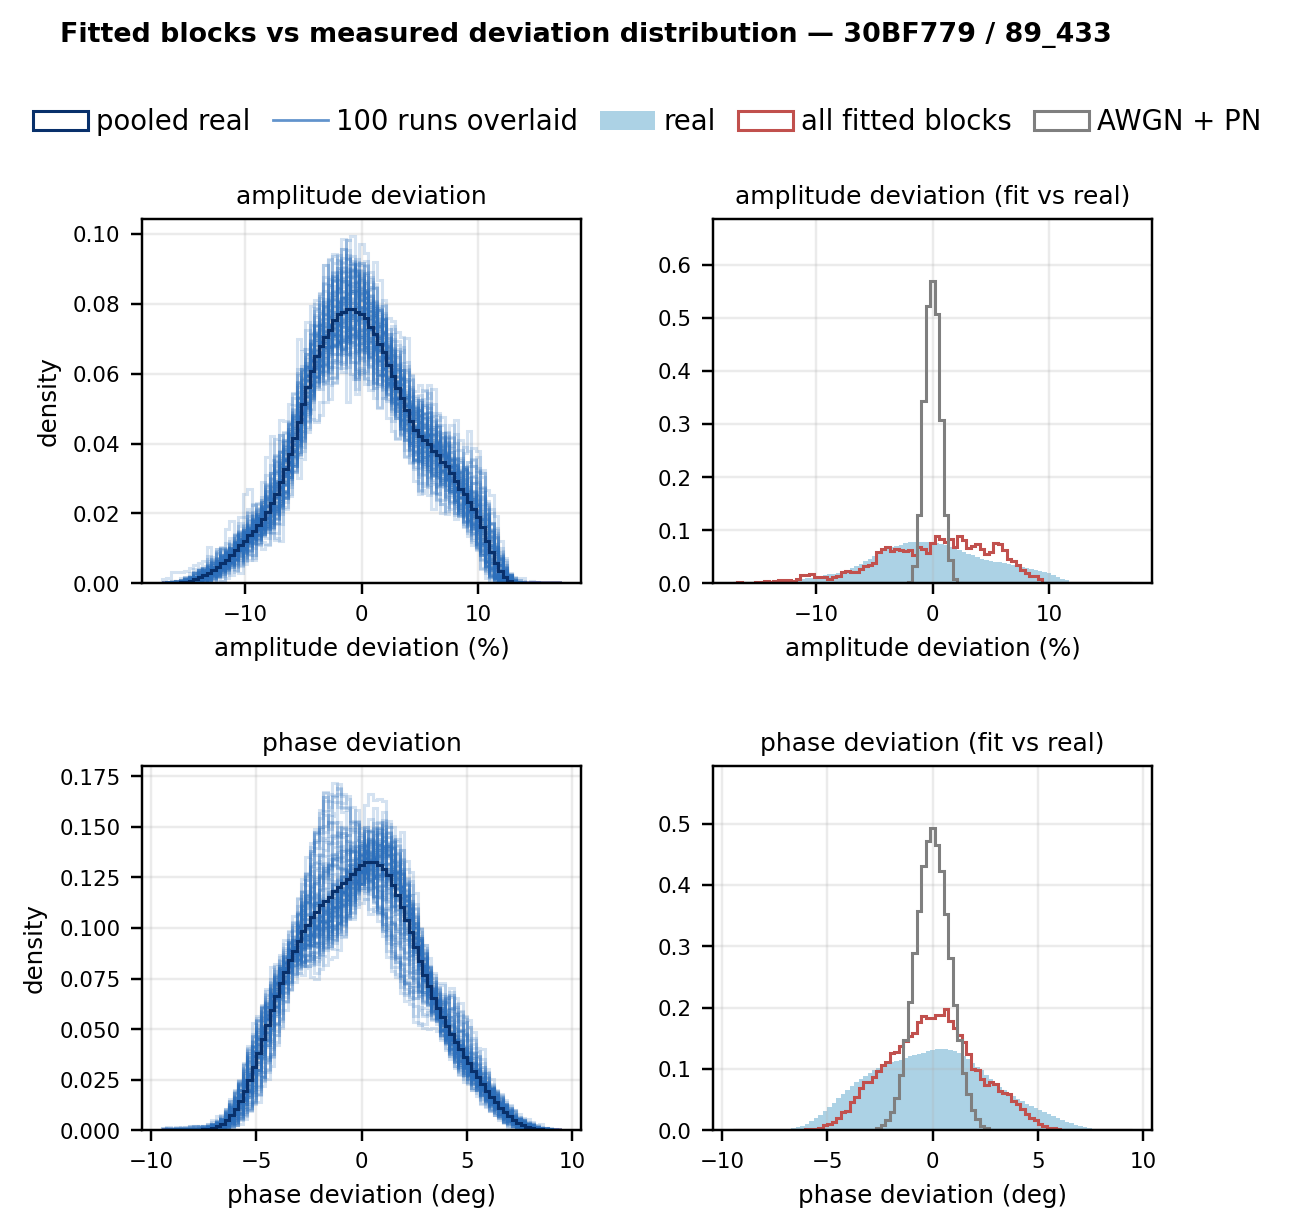

In [7]:
run("fig_fitted_blocks_dist.py", "30BF779", "89_433")
display(Image(str(FIGURES / "A4s_fitted_blocks_dist_30BF779_89_433.png")))

The gap between the red and grey curves is what the fitted blocks
contribute, and it is most of the distribution: without them the synthetic
spread collapses to 13 % of the measured amplitude and 29 % of the phase.

With them the chain reaches 96 % of the measured amplitude spread but only
76 % of the phase. The missing 1.84 degrees is a tangential term the three
fitted blocks do not produce — see the known limitations in the README.

Note also that the model's amplitude curve carries visible lattice structure
near +5 %, where the real distribution is smooth: three fixed taps give each
symbol a deviation drawn from a finite set, while real hardware varies within
the burst.

## Notes on reproducibility

**Capture dates are baked in.** The 20-day filter needs to know when each
session was recorded, and the logs carry no timestamp — the dates live in the
capture directory names, which are not shipped here. They are recorded as
`CAPTURE_DATES` in `analysis_scripts/session_vs_device.py`.

**Excluded sessions are named, not silently dropped.** `BAD_JULY_SESSIONS`
lists the four bad-carrier captures with the reason beside each, in both
`session_vs_device.py` and `radio_population_bars.py`.

**Figures are written to `figures/`** and overwrite in place, so re-running is
safe.